<a href="https://colab.research.google.com/github/asdevcoder/asdevcoder.github.io/blob/master/Group_34_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stroke Prediction Model: A Machine Learning Project**
A Full End-to-End Machine Learning Project leveraging both supervised (classification) and unspervised (clustering) learning

**Group Number:** 34

**Dataset Name:** Stroke Prediction Dataset

**Depth Track Chosen**: Clustering Depth

**Full Team Members:**
1. Anuhi Mustapha Onotu
2. Anehita Benita Enaboifoh
3. Azubuike Godswill
4. Sarah Diti Blazon
5. Timileyin Ayoola
6. Opeyemi Taofeek ABDULMUMEEN
7. Muoneke Praise Chidera
8. ⁠Emmanuel Jacob
9. Okhiku Victory Olohitare

## **Part 1: Data Foundation (15%)**

In [1]:
#  importing essential libraries
import pandas as pd
import numpy as np

#==============================================

import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

#===================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    silhouette_score
)

#  ===================================================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


sns.set_style('whitegrid')

In [2]:
# from google.colab import userdata
# userdata.get('KAGGLE_API_KEY')

**1. Load the dataset directly from Kaggle inside the notebook**

In [3]:
# # Download dataset using kagglehub
# !kaggle datasets download -d fedesoriano/stroke-prediction-dataset

# # Unzip dataset
# !unzip stroke-prediction-dataset.zip

# # Load dataset
# df = pd.read_csv('stroke_data.csv')

# df.head()

## Load the dataset from URL
df = pd.read_csv("https://raw.githubusercontent.com/anuhimustee/Stroke-Prediction-Model/refs/heads/main/data/healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


**2. Push the data into SQLite Database**

In [4]:
conn = sqlite3.connect('stroke_data.db')
df.to_sql('stroke_data', conn, if_exists='replace', index=False)

5110

**3. Run at least 3 SQL queries that reveal something useful about the data. Each query must be followed by a markedonw cell explainin gwhat you learned**

> 1. What is the gender distribution in the dataset
2. What is the average bmi in the stroke data?
3. What catefory of smoking_status is the highest?




In [5]:
# What is the gender distribution in the dataset?

pd.read_sql_query("""
SELECT
    gender,
    COUNT(*) AS total_patients,
    SUM(stroke) AS stroke_cases,
    ROUND(100.0 * SUM(stroke) / COUNT(*), 2) AS stroke_rate
FROM stroke_data
GROUP BY gender
ORDER BY stroke_rate DESC;
""", conn)

,gender,total_patients,stroke_cases,stroke_rate
0,Male,2115,108,5.11
1,Female,2994,141,4.71
2,Other,1,0,0.00


> The dataset is dominated by female patients, who make up the largest portion of the population. However, males show a slightly higher stroke rate (**5.11%**) compared to females (**4.71%**), suggesting that male patients in this dataset may have a marginally higher stroke risk.

In [6]:
# What is the average bmi in the stroke data?
pd.read_sql_query(
    """
    SELECT ROUND(AVG(bmi),2) as avg_bmi
    FROM stroke_data
    """,
    conn

)

,avg_bmi
0,28.89


> The average BMI in the dataset is 28.89, which falls within the overweight range. This suggests that, on average, the population may be at increased risk of health conditions such as hypertension, diabetes, and cardiovascular disease, all of which are associated with higher stroke risk.

In [7]:
# What catefory of smoking_status is the highest?
pd.read_sql_query(
    """SELECT smoking_status, COUNT(*) as count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage_Count
    FROM stroke_data
    GROUP BY smoking_status
    ORDER BY count DESC;
    """,
    conn)

,smoking_status,count,percentage_Count
0,never smoked,1892,37.03
1,Unknown,1544,30.22
2,formerly smoked,885,17.32
3,smokes,789,15.44


> The largest smoking category in the dataset is “never smoked”, representing about 37% of all patients. This suggests that a significant portion of the population does not actively smoke, although stroke can still occur due to other factors such as age, hypertension, glucose level, and heart disease.

> The high percentage of “Unknown” smoking status also indicates missing or incomplete lifestyle information, which could affect the accuracy of smoking-related health analysis.

**4.Perform initial exploratory data analysis: shape, types,missing values, distribution of the target column,distributions of three to five key features.**

In [8]:
#  Getting the shape of the dataset
df.shape

print(f"The shape of the stroke dataset is {df.shape}")

print("="*50)

print("\nBelow is the data types of each of columns:")
print(df.dtypes)

print("="*50)

The shape of the stroke dataset is (5110, 12)

Below is the data types of each of columns:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


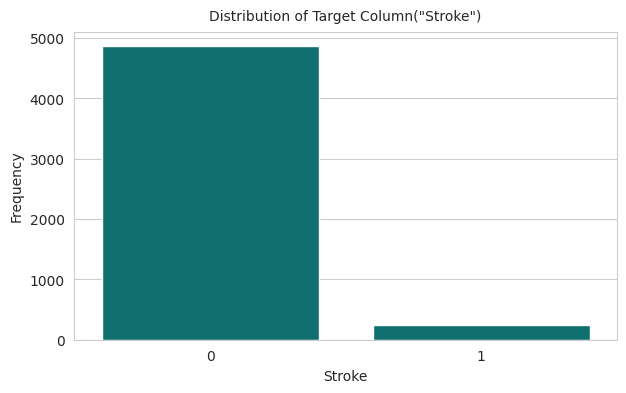

In [9]:

plt.figure(figsize=(7,4))
sns.countplot(x=df['stroke'], color = 'teal', edgecolor = None)
plt.title('Distribution of Target Column("Stroke")', fontsize = 10, y=1.01)
plt.xlabel("Stroke")
plt.ylabel("Frequency")
plt.show()

print()

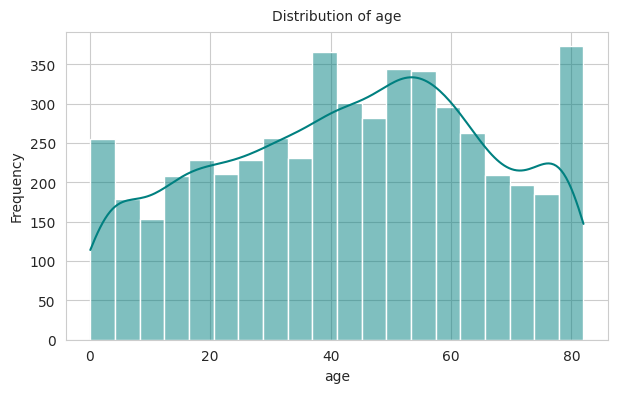

The Skewness of the age is -0.1370593225984694
The Kurtosis of the age is -0.9910102432016696


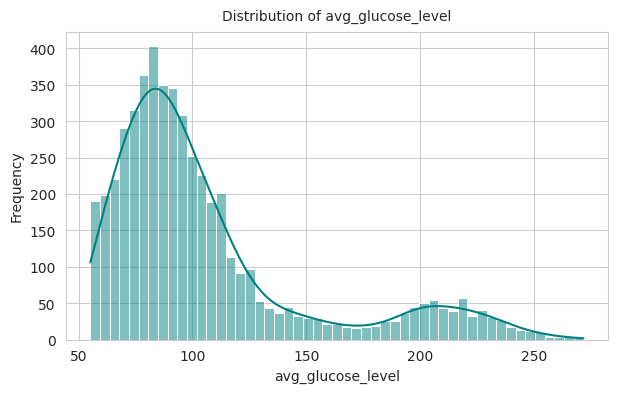

The Skewness of the avg_glucose_level is 1.5722838665030459
The Kurtosis of the avg_glucose_level is 1.6804785404038278


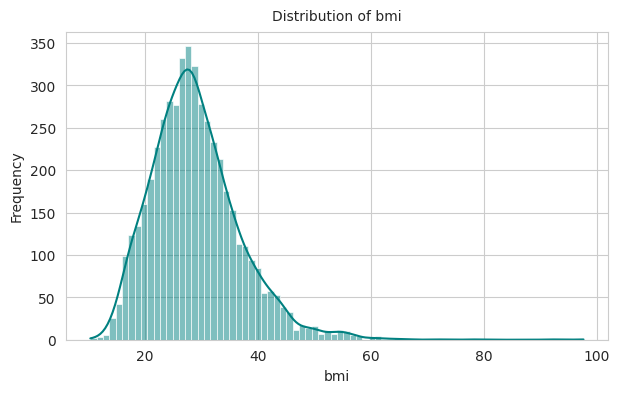

The Skewness of the bmi is 1.0553402052962912
The Kurtosis of the bmi is 3.3626591656236746


In [10]:
# Distribtion of 3 key features

key_feat = ['age','avg_glucose_level','bmi']

for col in key_feat:
  plt.figure(figsize=(7,4))
  sns.histplot(x=df[col], kde=True, color = 'teal')
  plt.title(f'Distribution of {col}', fontsize = 10, y=1.01)
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

  print("="*50)
  print(f"The Skewness of the {col} is {df[col].skew()}")
  print(f"The Kurtosis of the {col} is {df[col].kurtosis()}")

**5. Clean the data with a justification in markdown for every step. No blanket fillna. If you drop rows, explain why those rows had no signal**


In [11]:
#  Checking for missing values
df.isnull().sum()

missing_values = df.isnull().sum()
missing_percent = df.isnull().mean()

missing_summary = pd.DataFrame({"MissingValues":missing_values,
                      "MissingPercent": round(missing_percent,2)})

print("Missing Values Summary:")
print(missing_summary)

print("Only BMI column has missing values")

Missing Values Summary:
                   MissingValues  MissingPercent
id                             0            0.00
gender                         0            0.00
age                            0            0.00
hypertension                   0            0.00
heart_disease                  0            0.00
ever_married                   0            0.00
work_type                      0            0.00
Residence_type                 0            0.00
avg_glucose_level              0            0.00
bmi                          201            0.04
smoking_status                 0            0.00
stroke                         0            0.00
Only BMI column has missing values


Only the BMI column contains a missing value of **201 out of 5110 records** which i sequivalent **0.04%** of the entire dataset.
Fundamentally, the percentage of missing vlaue is extremly small and insignifacnt to the entire dataset if we decide to drop it. So I am going to be replace the missing values with the median value of the BMI.


In [12]:
#  Cleaning the missing values

df.fillna(df['bmi'].median(), inplace=True)

# Checking for the missing values again
df.isnull().sum()


# plt.figure(figsize=(7,4))
# sns.boxplot(x=df['bmi'])
# plt.show()


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [13]:
#  Remove the Other row in the Gender Column
df = df[df['gender'] != 'Other']
df.shape

(5109, 12)

## **Part 2: Feature Engineering and Encoding (20%)**

**6. Create at least three new features from existing columns. Examples to get you thinking:**

Bin a continuous column into meaningful groups

*   Bin a continuous column into meaningful groups
*   Count how many times something happens per row
*   Compute a ratio between two columns
*   Combine two columns into an interaction term




**Reason for the New Features:** The BMI is a measure of whether a person's body wegiht to healthy is realtive to their height. While the measures are diverse, a feature that clearly outline the what each numerical value represent can better help the model learn better the distribution and interaction of bmi category relative to the target variable (stroke)


| BMI Range   | Meaning     |
| ----------- | ----------- |
| < 18.5      | Underweight |
| 18.5 – 24.9 | Normal      |
| 25 – 29.9   | Overweight  |
| 30+         | Obese       |


The category itself carries a more healthier meaning.

In [14]:
# @title Creating a new feature called "BMI Category"
df['bmi_category'] = pd.cut(df['bmi'],
                            bins=[0, 18.5, 24.9, 29.9, float('inf')],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])


**Reason for the New Features:** Given the age as a numerical values, the idea to create an age group gives a holistic overview of the different age group in the dataset which can further offer new and deeper inisghts into how age correlates with stoke.


---

For example, after the code, we have a boxplot that shows the distribution of age amogst the each stroke outcome that gives a better understanding.



> Refer to the graph beneath the code





In [15]:
# creating a new features called age_group
df['age_group'] = pd.cut(df['age'],
                        bins=[0, 18, 35, 55, float('inf')],
                        labels=['Teen', 'Adult', 'Middle-Aged', 'Senior'])
                        #  label = ['Teen', 'Adult', 'Middle-Aged', 'Senior'])

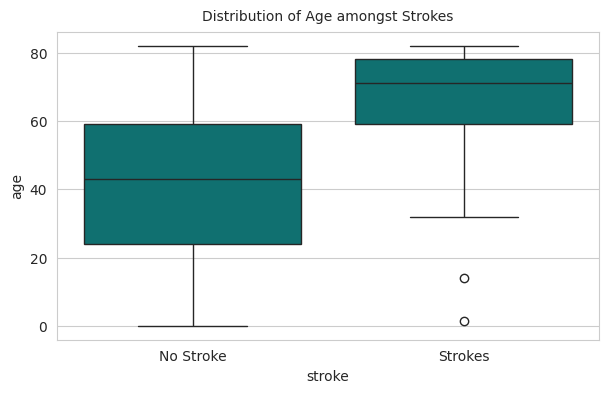

In [16]:
# Plotting stroke distribution amongst ages
plt.figure(figsize=(7,4))
sns.boxplot(x=df['stroke'], y=df['age'], color = 'teal')
plt.title('Distribution of Age amongst Strokes', fontsize = 10, y=1.01)
plt.xticks(ticks=[0,1], labels=["No Stroke","Strokes"])
plt.show()

**Reason for the New Features:**
Stroke is primarily caused  as a result of blood flow tot he brian is interrupted.

This can happen because:

1. A blood vessel is blocked
2. A blood vessel bursts

> The brain then lacks oxygen, which can damage brain cells



* Hypertension is caused by High Blood Pressure which can ultimately result in the rapture of a artries. This alone is a strong indicator of stroke.
* Heart Disease affects blood circulation which can lead to insufficient flow of blood to the brain hence can be a leading cause of stoke.

This two factors are chronic disease are dangerous that when both are present can increase the likelihood of stroke

Combining the major disease indicators into one feature as chronic_conditions can reveal a pattern of likelihood.


In [17]:
# Chronic disease count
df['chronic_conditions'] = (df['hypertension'] + df['heart_disease'])

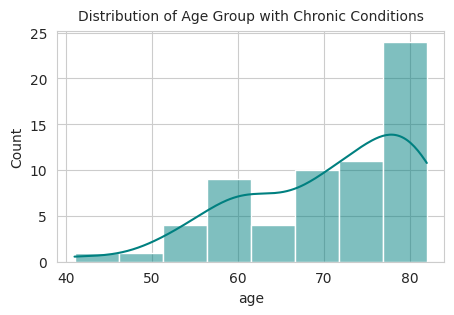




Older Patient with age 80+ then to have the 2 chronic conditions (i.e heart disease and hypertension)


In [18]:
# Filtering out data where the patient has two or more diseases together.
dff = df[df['chronic_conditions']>=2]

# Finding the distribution
plt.figure(figsize=(5,3))
sns.histplot(dff['age'], kde=True, color = 'teal')
plt.title('Distribution of Age Group with Chronic Conditions', fontsize = 10, y=1.01)
plt.show()

print("\n")
print("\nOlder Patient with age 80+ then to have the 2 chronic conditions (i.e heart disease and hypertension)")

**Reason for the New Features:** We create a categorical indicator to capture the high threshold of glucose level. So, if a patient's average glucose level is above 140, their high_glucose value will be 1, indicating they have high glucose. Otherwise, it will be 0.

In [19]:
# High_Glucose Indicator

df['high_glucose'] = (df['avg_glucose_level'] > 140).astype(int)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_group,chronic_conditions,high_glucose
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese,Senior,1,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Overweight,Senior,0,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese,Senior,1,0
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Obese,Middle-Aged,0,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Normal,Senior,1,1


**Encode all categorical columns. Choose between label encoding and one hot encoding for each.** **Justify your choice. Use drop_first when appropriate and explain why. Scale your features. Choose between StandardScaler and MinMaxScaler and justify.**

In [20]:

#  Extracting all categorical columns out even those with 0s and 1s by default.
cat_cols = ['gender','hypertension','heart_disease','ever_married','work_type',
            'Residence_type','smoking_status','bmi_category','chronic_conditions','age_group','high_glucose']

#  Converting the categorical columns to an object datatypes in order to be uniform
df[cat_cols] = df[cat_cols].astype('object')

# checking the datatypes of the dataset
df.dtypes



,0
id,int64
gender,object
age,float64
hypertension,object
heart_disease,object
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [21]:
X = df.drop(columns = ['stroke','id']) # dropping the id column as it is irrelevant to our model training.
y = df['stroke']


In [22]:
X.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,bmi_category,age_group,chronic_conditions,high_glucose
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,Obese,Senior,1,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,Overweight,Senior,0,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,Obese,Senior,1,0
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,Obese,Middle-Aged,0,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,Normal,Senior,1,1


['gender', 'ever_married','work_type','Residence_type','smoking_status','bmi_category' ,'age_group']

**Splitting the data before preprocessing**

In [23]:
# Split the data into train and test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Applying OneHotEncoder**

In [24]:
# categorical col for onehotencoder
enc_cols = ['gender', 'ever_married','work_type','Residence_type','smoking_status','bmi_category' ,'age_group']

# Create encoder
encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

# FIT on training data
X_train_encoded = encoder.fit_transform(
    X_train[enc_cols]
)

# TRANSFORM test data
X_test_encoded = encoder.transform(
    X_test[enc_cols]
)

#  Convert Encoded Arrays to DataFrames
encoded_columns = encoder.get_feature_names_out(enc_cols)

X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

# Remove Original Categorical Columns
X_train = X_train.drop(columns=enc_cols)

X_test = X_test.drop(columns=enc_cols)


# Combine Back Together
X_train = pd.concat(
    [X_train, X_train_encoded_df],
    axis=1
)

X_test = pd.concat(
    [X_test, X_test_encoded_df],
    axis=1
)



**Applying StandardScaler**

In [25]:
num_cols = df.select_dtypes(include='number').drop(columns=['id','stroke']).columns.tolist()
num_cols

['age', 'avg_glucose_level', 'bmi']

In [26]:

scaler = StandardScaler()

# FIT on TRAIN
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

# TRANSFORM TEST
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

##### **Summary Result from Data Preprocessing**

In [27]:
print(f"X_train has a data shape of {X_train.shape[0]} rows and {X_train.shape[1]} columns")
print(f"X_test has a data shape of {X_test.shape[0]} rows and {X_test.shape[1]} columns")
print(f"y_train has a data shape of {y_train.shape[0]} rows")
print(f"y_test has a data shape of {y_test.shape[0]} rows")

X_train has a data shape of 4087 rows and 23 columns
X_test has a data shape of 1022 rows and 23 columns
y_train has a data shape of 4087 rows
y_test has a data shape of 1022 rows


## **Part 3: Clustering Analysis(20%)**

In [28]:
"""Merging preprocessed X_train and X-test into a single dataframe to use for
clustering analysis"""

clustering_data=pd.concat([X_train, X_test]).sort_index()
clustering_data


,age,hypertension,heart_disease,avg_glucose_level,bmi,chronic_conditions,high_glucose,gender_Male,ever_married_Yes,work_type_Never_worked,...,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,age_group_Middle-Aged,age_group_Senior,age_group_Teen
0,1.048639,0,1,2.748850,1.001626,1,1,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.783615,0,0,2.156077,-0.097041,0,1,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.622857,0,1,0.000558,0.471681,1,0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.253567,0,0,1.462568,0.717265,0,1,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
4,1.578687,1,0,1.527262,-0.626986,1,1,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1.622857,1,0,-0.495733,-0.097041,1,0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5106,1.667028,0,0,0.432154,1.441093,0,0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,-0.364822,0,0,-0.512746,0.226096,0,0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5108,0.341909,0,0,1.351982,-0.420178,0,1,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


**7. Run K-Means with K from 2 to 10. Plot the elbow curve and the silhouette scores**


In [29]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustering_data)
    inertias.append(km.inertia_)

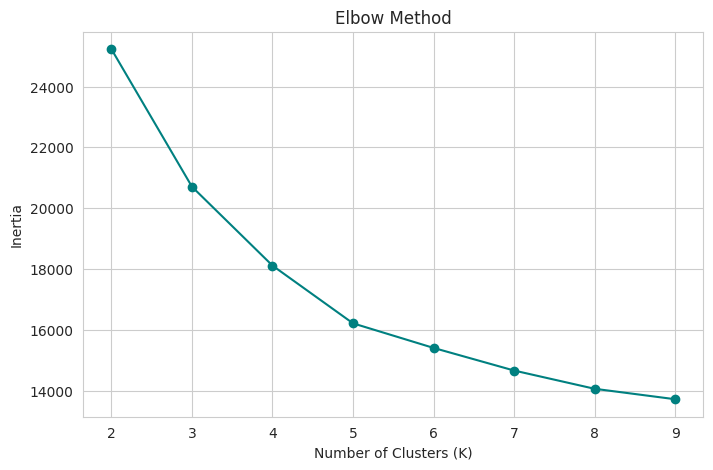

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o", color = 'teal')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

**Silhouette Score-**
The silhouette score tells us how well-separated the clusters are. It ranges from -1 to 1, where higher is better.

In [31]:
#  Getting the silhoute_score

silhouette_scores = []
k_range_sil = range(2, 10)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(clustering_data)
    score = silhouette_score(clustering_data, labels)
    silhouette_scores.append(score)

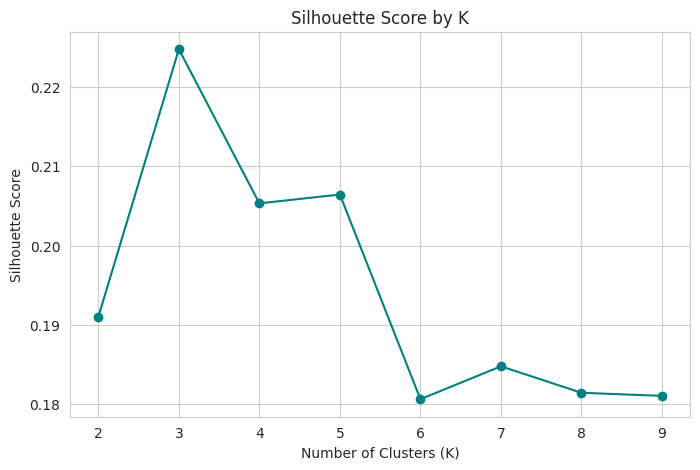

In [32]:
#  plotting the sihouette_score against the K values

plt.figure(figsize=(8, 5))
plt.plot(k_range_sil, silhouette_scores, marker="o", color="teal")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K")
plt.grid(True)
plt.show()

**8. Pick a final K and explain the choice using both signals**
Combining what the elbow tells us with what the silhouette tells us, K=3 is a reasonable choice for this dataset. Different K values are defensible.

K=3 was selected because:

1. The elbow curve showed a noticeable bend at K=3,
   indicating diminishing returns afterward.

2. The silhouette score remained relatively high at K=3,
   suggesting well-separated and cohesive clusters.

**So we choose the final value of K = 3**

**9. Profile each cluster in plain English by computing group means and giving each
cluster a name (for example, “long tenure budget customers” or “high spend new
arrivals”)**

In [33]:
final_k =3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(clustering_data)

In [34]:
df["kmeans_cluster"] = kmeans_labels
df["kmeans_cluster"].value_counts().sort_index()

,count
kmeans_cluster,
0,2998
1,1379
2,732


In [35]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_group,chronic_conditions,high_glucose,kmeans_cluster
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Obese,Senior,1,1,2
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1,Overweight,Senior,0,1,2
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese,Senior,1,0,0
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Obese,Middle-Aged,0,1,2
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Normal,Senior,1,1,2


In [36]:
cluster_profile = df.groupby('kmeans_cluster').agg({
    "age": "mean",
    "avg_glucose_level": "mean",
    "bmi": "mean"
}).round(2)

cluster_profile

,age,avg_glucose_level,bmi
kmeans_cluster,,,
0,52.19,88.52,30.90
1,14.70,93.47,22.30
2,60.27,202.16,32.87


| Clusters | Characteristics                            | Suggested Name        |
| ------- | ------------------------------------------ | --------------------- |
| 0       | Middle-aged, overweight, moderate | Moderate-Risk Adults    |
| 1       | Older Individuals, Obese, very high glucose level                | High-Risk Odler Patients |
| 2       | Young,health BMI and glucose | Healthy Young Individuals  |



#### **Clustering Insights**

From the Analysis I was able to identified three meaningful patient segments:
1. A relatively healthy youth population
2. A moderate-risk middle-aged overweight group
3. A high-risk elderly diabetic/obese group

**This kind of segmentation can help healthcare providers:**

* Prioritize preventive care
* Identify high-risk patients
* Personalize treatment plans
* Improve stroke prevention strategies



**10. Visualize the clusters in two dimensions using PCA**

In [37]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(clustering_data)

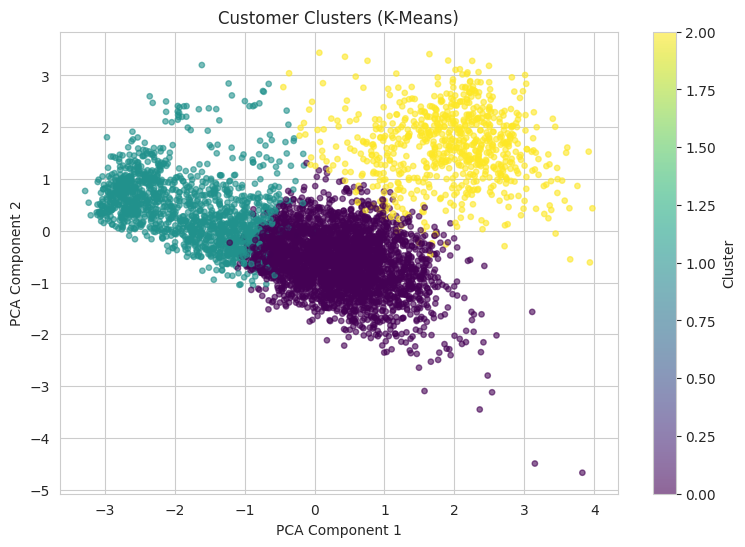

In [38]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap="viridis", alpha=0.6, s=15
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Clusters (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

## **Part 4: Classification (20%)**

**11. Set up the supervised learning task. Use train_test_split with stratify=y**

Train & Test Split has already beeing done before preprocessings. Hence we just call out the variable names
- X_train
- X_test
- y_train
- y_test  respectively to use for our supervised learning task

**12. Train at least three classifiers of your choice from those we covered in class. You decide which models to use and why. Justify each choice in a markdown cell**



### Classifier 1: Logisitic Regression

The first model to use is the logisitic aregression to serve as a baseline model for classification model. It is simple and intuitive to sue.

Logistic regression draws a straight boundary between the "No Stroke" and "Yes Stroke" categories of feature space.
Despite the word "regression" in its name, it is a classifier. It outputs the probability of belonging to each class.

In [39]:
#  Using Logistic Regression as the baseline classifer

lg = LogisticRegression(max_iter=1000)
lg.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [40]:
y_pred_lr = lg.predict(X_test)

In [41]:
y_proba_lr = lg.predict_proba(X_test)[:, 1]

**13. Evaluate each model on the full metric suite: accuracy, precision, recall, F1,ROC AUC. Plot a confusion matrix for each**



In [42]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98       972
           1       1.00      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.98      0.51      0.51      1022
weighted avg       0.95      0.95      0.93      1022



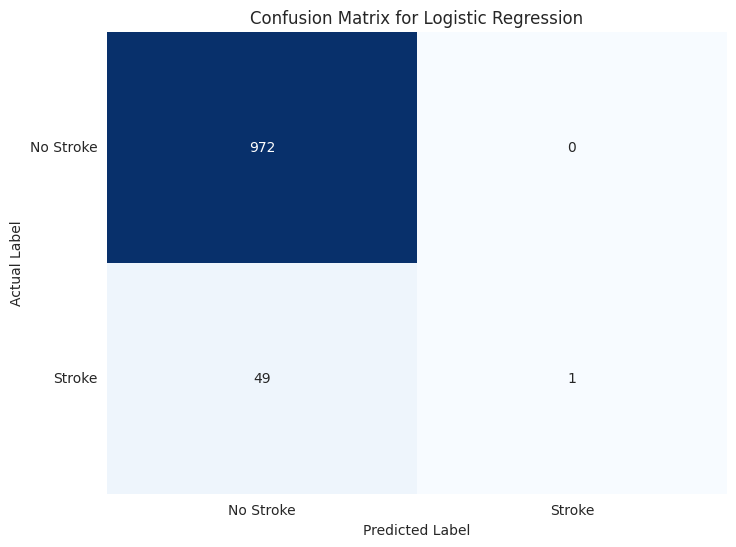

In [43]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Logistic Regression")
plt.xticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'])
plt.yticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'], rotation=0)
plt.show()

The confusion matrix shows where the model is making mistakes. Rows are actual, columns are predicted. Watch the off-diagonal cells closely. In a health prediction like that of the stroke, false negatives (patient we predicted would not have stroke but have actually haveit) are usually more costly than false positives.

---

### Classifier 2: Decision Tree Classifier

A decision tree asks yes/no questions to split customers into groups. Each path from the root to a leaf is a rule the model learned.

In [44]:
dt = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [45]:
y_pred_dt = dt.predict(X_test)

In [46]:
y_proba_dt = dt.predict_proba(X_test)[:,1]

**13. Evaluate each model on the full metric suite: accuracy, precision, recall, F1,ROC AUC. Plot a confusion matrix for each**



In [47]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.27      0.08      0.12        50

    accuracy                           0.94      1022
   macro avg       0.61      0.53      0.55      1022
weighted avg       0.92      0.94      0.93      1022



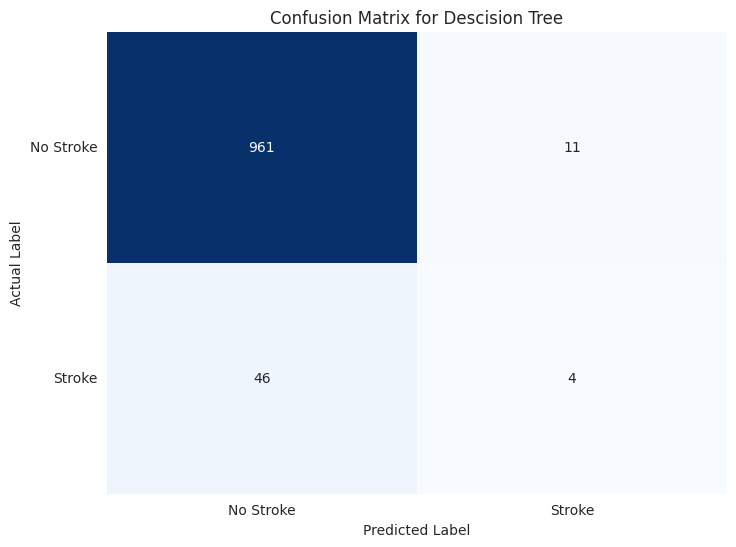

In [48]:

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Descision Tree")
plt.xticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'])
plt.yticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'], rotation=0)
plt.show()

In [49]:
dt_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False).head(10)

dt_importance

,feature,importance
0,age,0.371458
3,avg_glucose_level,0.216071
4,bmi,0.196817
8,ever_married_Yes,0.043855
2,heart_disease,0.039828
7,gender_Male,0.028039
10,work_type_Private,0.026971
1,hypertension,0.019839
14,smoking_status_formerly smoked,0.015730
15,smoking_status_never smoked,0.013832


---

### Classifier 3: Random Forest Classifier

A random forest trains many decision trees on random subsets of the data and averages their predictions. The result is usually more accurate and more stable than a single tree.

In [50]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [51]:
y_pred_rf = rf.predict(X_test)

In [52]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

**13. Evaluate each model on the full metric suite: accuracy, precision, recall, F1,ROC AUC. Plot a confusion matrix for each**



In [53]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


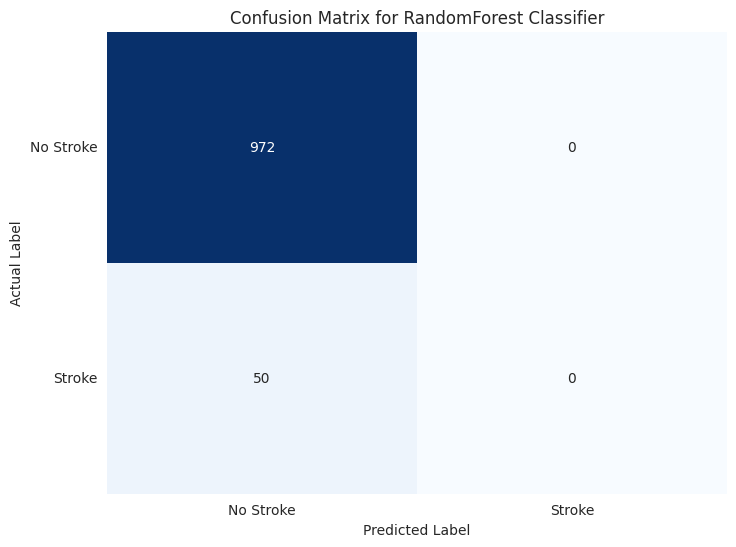

In [54]:

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for RandomForest Classifier")
plt.xticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'])
plt.yticks(ticks=[0.5, 1.5], labels=['No Stroke', 'Stroke'], rotation=0)
plt.show()

In [55]:
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

rf_importance

,feature,importance
0,age,0.254231
3,avg_glucose_level,0.167735
4,bmi,0.135082
21,age_group_Senior,0.113178
5,chronic_conditions,0.049508
6,high_glucose,0.029408
1,hypertension,0.027429
7,gender_Male,0.023534
10,work_type_Private,0.022670
2,heart_disease,0.022206


**14. Build a single comparison table with the models in rows and metrics in columns**

---

### Model Comparison
We stack all three models side by side using the metrics from the evaluation lecture.

In [56]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

In [57]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", y_test, y_pred_lr, y_proba_lr),
    evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt),
    evaluate_model("Random Forest", y_test, y_pred_rf, y_proba_rf),
])

results.round(3)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.952,1.000,0.02,0.039,0.841
1,Decision Tree,0.944,0.267,0.08,0.123,0.686
2,Random Forest,0.951,0.000,0.00,0.000,0.829


No single metric tells the full story. Accuracy can look good simply because most patients do not have stroke, in fact look closely at the recall column for the stroke class in each classification report. The model is missing many of the patients who actually have stroke. That is the class imbalance problem, and it is what we tackle next.

## **Part 5: Imbalance Handling (10%)**

**15.Apply at least two of the three techniques: class weights, threshold tuning, SMOTE**

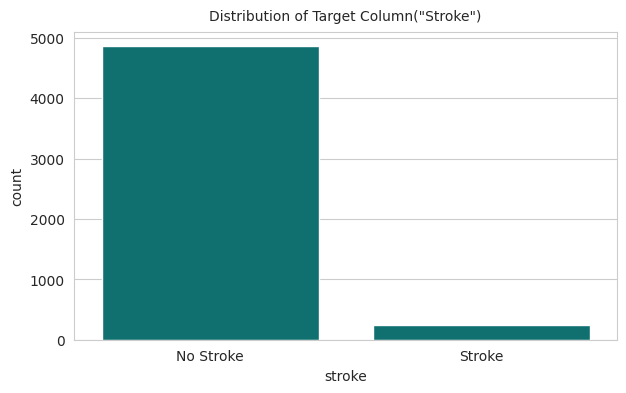



stroke
0    4860
1     249
Name: count, dtype: int64
--------------------------------------------------
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


In [58]:
plt.figure(figsize=(7,4))
sns.countplot(x=df['stroke'], color = 'teal', edgecolor = None)
plt.title('Distribution of Target Column("Stroke")', fontsize = 10, y=1.01)
plt.xticks(ticks = [0,1],labels = ['No Stroke', "Stroke"])
plt.show()
print("\n")
# print("-"* 50)

outcome = df['stroke'].value_counts()
outcome_percent = (df['stroke'].value_counts(normalize=True)*100).round(2)
print(outcome)
print("-"* 50)
print(outcome_percent)

The **No Stroke** group has about **95%** records than the Stroke group.
This means the dataset is extremely imbalanced, because one class appears much more  (**i.e 90%**) often than the other.

**Why Class Imbalance Is a Problem**

* In machine learning, class imbalance can mislead the model.

* The model may learn to favor the majority class (No Stroke).

* It could predict “No Stroke for almost everyone.

Even though accuracy may look high, the model would miss many real Stroke cases.


We try 2 out of 3 common techniques to push the model towards catching more of the minority class.

### Approach 1: Class Weights

We tell the model that mistakes on the minority class hurt more than mistakes on the majority class. In sklearn we set `class_weight='balanced'` and the model automatically weights each class inversely to how often it appears.

In [59]:
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=10, min_samples_split=20, n_jobs=-1,
                       random_state=42)

In [60]:
y_pred_rf_bal = rf_balanced.predict(X_test)

In [61]:
y_proba_rf_bal = rf_balanced.predict_proba(X_test)[:, 1]

### Approach 2: SMOTE

SMOTE stands for Synthetic Minority Over-sampling Technique. It generates new minority-class data points by picking a real minority point, finding its nearest minority neighbours, and creating a new point along the line between them. It does not just duplicate rows.

The critical rule: only apply SMOTE to training data, never to the test set. The test set must reflect the real-world distribution, otherwise your evaluation is meaningless.

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [63]:
y_train_smote.value_counts()

,count
stroke,
0,3888
1,3888


The training set is now balanced. We refit Random Forest on the resampled data, then evaluate on the original test set.

In [64]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [65]:
y_pred_rf_smote = rf_smote.predict(X_test)

In [66]:
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

In [67]:
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       972
           1       0.17      0.50      0.25        50

    accuracy                           0.85      1022
   macro avg       0.57      0.69      0.58      1022
weighted avg       0.93      0.85      0.89      1022



---
##### **16.Build a comarison table showing baseline versus each technique you applied**



In [68]:
# y_pred_threshold = (y_proba_rf >= 0.3).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline RF", y_test, y_pred_rf, y_proba_rf),
    evaluate_model("RF + class_weight", y_test, y_pred_rf_bal, y_proba_rf_bal),
    evaluate_model("RF + SMOTE", y_test, y_pred_rf_smote, y_proba_rf_smote),
])

imbalance_results.round(3)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline RF,0.951,0.000,0.00,0.00,0.829
1,RF + class_weight,0.836,0.189,0.72,0.30,0.834
2,RF + SMOTE,0.853,0.167,0.50,0.25,0.816


Each technique trades precision for recall in slightly different ways. There is no single winner, only the option that matches your business cost.

We tried class weights first because it is one parameter and works well most of the time. However, since our data is extremely imbalance which is severe given a ration of (95/5) we reach for SMOTE.

But the most optimal approach is with the Class_Weight

## **Part 6: The Tie in (5%)**

**17. Take the K-Means cluster labels from Part 3 and compute the rate of the positive class within each cluster**

In [69]:

stroke_rate_by_cluster = (
    df.groupby("kmeans_cluster")["stroke"]
    .apply(lambda series: (series == 1).mean())
    .rename("stroke_rate")
)

stroke_rate_by_cluster.round(3)

,stroke_rate
kmeans_cluster,
0,0.051
1,0.001
2,0.127


**18. Were any clusters strong predictors of the label? Explain what this tells you about your data**

---

Cluster 1 has a very high stroke rate of 12.7% which is very high relative tot he dataset average. This means that K-Means discovered a naturally occuring subgroup of people with similiar characteristics that are strongly associated with strke. **Thus Cluster 1 is a strong predictor**.


Yes — Cluster 1 appears to be a meaningful high-risk subgroup and can be considered strongly associated with the stroke label.

The clustering results suggest that:

The features contain strong underlying health-risk patterns
Stroke risk is not randomly distributed
Patients naturally group into low-, medium-, and high-risk populations
The dataset has meaningful structure that supervised models can learn from

This is actually a very good sign for downstream predictive modeling

## **Part 7: Conclusion and Recommendations (10%)**

**19. Which model would you deploy and why?**

---

I would deploy the Random Forest model because amonsgst the models testeds such as Logistic Regression, Decision Tree and Random Forest, the Random FOrest performed best overall based on the evaluation metrics such as ROC-AUC, Recall, F1-Score and Generalization ability.

My choice of Random Forest Model is also because it handles nonlinear relationship which is the case of the storke prediciton which is not a ismple linear problem. It also has better performanc eon Imbalanced dataset as with the case of our data i.e since stroke cases are rate, accuracy is alon is misleading. the model fenerally achieved better Recall and ROC-AUC.

Other reasons includes:
- Feature Importance: It provides feature importance scores, helping to idenitify key strioke drivers.
- More Stable than a single decision tree: A single decision tree can overfit easily while Random Forest solves this problem etc




**20. What would you do differently if you had another month?**

---

I would focus primairy on improving model performance, data quality and medical realism.

How I will achieve this is by Handling Class imbalance more aggressively. Our dataset reveals that very few patients actually had stroke hence will expereiment with other data balancing tecqhiques such as oversmapling, undersamples strategies to improve Recall and F1-score.

Will perform hyperparameter tuning because the current models are likely used mostly default parameters.. I would use GridSearchCv and or Randomized SearchCV to optimize for tree depth, number of estimators, minimum smamples split and learning thresholds which could significantly improve performance.

Other things I would be is to:
1. Enginerr more health based features
2. Explore more advanced models like XGBoost etc.


**21. What did your clusters reveal that the classifier missed?**

---

The clustering analysis revealed hidden population structures that supervised classification alone may not clearly expose.

K-Means identified naturally occurring patient groups with dramatically different stroke rates:
| Cluster           | Stroke Rate |
| ----------------- | ----------- |
| High-risk cluster | 12.7%       |
| Moderate cluster  | 5.1%        |
| Low-risk cluster  | 0.1%        |


This revealed that stroke risk exists along population segments rather than only individual predictions.

The Classifer focuses mainly on Predicitng whethher an individiual patient has stroke while the clustering revealed that there are hidden subgroup structures within the population.

In summary, the Classification answers the question *"will this individual likely have stroke?"* while Clustering answers *"What types of patients exist in this dataset"?*


**22. What was the hardest decision your team made and why?**

---

The hardest decision my team made was determining how to handle the server class imbalance probelm.

This was difficult because the dataset contains far fewer stroke cases than non-stroke cases. This created a major tradeoff between overall accuracy and detecting actual stroke patients.

A model could achiever very high accuracy simply by prediciting "No Stroke" for almost everyone. However, such model would fail at identifiying truly at -risk patients

## **BONUS!(10%)**

#### **Chosen Depth Track: Clustering Depth**

---

1. Clustering Depth. Run K-Means at three different values of K (for example K=3,
K=5, K=7) on the same dataset. For each value, profile the clusters and explain
how the customer personas change as K grows. For the value of K you ultimately
recommend, build at least three named personas and pull a few representative
customer rows from each

### **K-Means for K = 3**

In [70]:
# taking value of k
k = 3
kmeans_k3 = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels_k3 = kmeans_k3.fit_predict(clustering_data)

df_k3 = df.copy()
df_k3["kmeans_cluster"] = kmeans_labels_k3

print(f"\n--- Profiling for K={k} ---")
cluster_profile_k3 = df_k3.groupby('kmeans_cluster').agg({
    "age": "mean",
    "avg_glucose_level": "mean",
    "bmi": "mean"
}).round(2)

cluster_profile_k3


--- Profiling for K=3 ---


,age,avg_glucose_level,bmi
kmeans_cluster,,,
0,52.19,88.52,30.90
1,14.70,93.47,22.30
2,60.27,202.16,32.87


How customer personas change as K grows As K increases, the clusters become more granular.

K=3: We observe three broad personas:

Cluster 0: These are Middle-Aged, average glucose level, and slighlty overweight. We can name them as **Moderate-Risk Adults**

Cluster 1: This cluster comprises of older, obese and has a very high glucose. Let's name them **"High-Risk Older Patients"**

Cluster 2: These are more of yung, healthy individuals with a relative low BMI/Glucose level. We name them **"Healthy Young Individuals"**



### **K-Means for K = 5**

---

In [71]:
# taking value of k
k = 5
kmeans_k5 = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels_k5 = kmeans_k5.fit_predict(clustering_data)

df_k5 = df.copy()
df_k5["kmeans_cluster"] = kmeans_labels_k5

print(f"\n--- Profiling for K={k} ---")
cluster_profile_k5 = df_k5.groupby('kmeans_cluster').agg({
    "age": "mean",
    "avg_glucose_level": "mean",
    "bmi": "mean"
}).round(2)

cluster_profile_k5


--- Profiling for K=5 ---


,age,avg_glucose_level,bmi
kmeans_cluster,,,
0,8.45,94.55,20.43
1,68.63,88.75,28.62
2,61.26,207.14,32.96
3,36.21,90.92,25.39
4,39.96,90.62,37.33


At K=5: We noticed that some clusters further split into a more granular characterists. For instance, the 'Moderate-Risk Adults' or 'Healthy Young Individuals' might differentiate further based on subtle differences in age, BMI, or glucose levels, leading to more refined definitions within those broader categories. The high-risk group might also splinter, revealing variations in the severity or combination of risk factors.

But there is a very important matrix that is staying consistent here, which is the High Older Risk patients. This is a very optimal cluster that reveals a more indepth smiliarities and characteristics wheich are odler people, high glucose level and are obese

### **K-Means for K = 7**

---

In [72]:

# Run K-Means for K=7
kmeans_k7 = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels_k7 = kmeans_k7.fit_predict(clustering_data)

df_k7 = df.copy()
df_k7["kmeans_cluster"] = kmeans_labels_k7

print("\n--- Profiling for K=7 ---")
cluster_profile_k7 = df_k7.groupby('kmeans_cluster').agg({
    "age": "mean",
    "avg_glucose_level": "mean",
    "bmi": "mean"
}).round(2)

cluster_profile_k7


--- Profiling for K=7 ---


,age,avg_glucose_level,bmi
kmeans_cluster,,,
0,24.34,91.98,25.11
1,66.48,89.58,34.61
2,69.25,88.76,25.93
3,39.58,90.76,37.37
4,61.43,208.19,33.01
5,45.63,91.34,25.73
6,7.09,94.24,20.01


How customer personas change as K grows
As K increases, the clusters become more granular.



K=7: At K=7, the segmentation becomes even more detailed. We further noticed some divisions within existing groups, such as separating **'healthy children'** from ***'healthy young adults'***, or identifying specific types of ***'high-risk'*** individuals based on their primary comorbidity (e.g., high glucose vs. hypertension). While this offers more precise targeting, it also increases complexity and might lead to less distinct differences between adjacent clusters.

---

The recommended K=3 provides the most interpretable and distinct personas without over-segmenting the data, which aligns with the elbow and silhouette score analysis.

In [73]:


# Named personas for K=3 (based on previous profiling)
print("\nPersona 1: Healthy Young Individuals (Cluster 2)")
print('='*60)
# Example: Young, healthy BMI, healthy glucose
persona1 = df_k3[df_k3['kmeans_cluster'] == 2].sample(3, random_state=42)[['age', 'gender', 'bmi_category', 'avg_glucose_level', 'stroke']]
persona1



Persona 1: Healthy Young Individuals (Cluster 2)


,age,gender,bmi_category,avg_glucose_level,stroke
4086,68.0,Male,Obese,145.25,0
73,63.0,Male,Overweight,228.56,1
1778,76.0,Male,Overweight,225.60,0


In [74]:
print("\nPersona 2: Moderate-Risk Adults (Cluster 0)")
print('='*60)
# Example: Middle-aged, normal to overweight BMI, average glucose, moderate risk factors

df_k3[df_k3['kmeans_cluster']==0].sample(3, random_state=42)[['age','avg_glucose_level','bmi','stroke']]


Persona 2: Moderate-Risk Adults (Cluster 0)


,age,avg_glucose_level,bmi,stroke
2331,37.0,91.68,32.4,0
1563,63.0,98.46,30.6,0
231,79.0,97.73,21.5,1


In [75]:
print("\nPersona 3: High-Risk Older Patients (Cluster 1)")
print('='*60)
# Example: Older, obese, high glucose, presence of hypertension/heart disease

df_k3[df_k3['kmeans_cluster']==1].sample(3, random_state=42)[['age','avg_glucose_level','bmi','stroke']]




Persona 3: High-Risk Older Patients (Cluster 1)


,age,avg_glucose_level,bmi,stroke
2388,10.0,61.34,19.1,0
3446,21.0,88.51,20.5,0
2530,16.0,134.23,30.6,0


# **THE END!!!**🙏🙏🙏

---